In [10]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn

Matplotlib is building the font cache; this may take a moment.



Here is some code to do forward propagation of a DNN.

In [39]:
def relu(z):
    # relu activation
    if z<=0:
        return 0
    else:
        return z

def drelu(z):
    # relu derivative
    if z<=0:
        return 0
    else: 
        return 1

def sigmoid(z):
    # sigmoid function
    return 1/(1+np.exp(z))

def dsigmoid(z):
    # derivative of the sigmoid function
    return sigmoid(z)*(1-sigmoid(z))

def error_f(y, t):
    # compute the error function
    return -np.mean(y*np.log(t) + (1-y)*np.log(1-t)  )

def fwd_prop(x, w1, b1, w2, b2):
    # forward propagation
    # x = inputs
    # w1, b1 = weights and biases of first layer
    # w2, b2 = weights and biases of second layer    
    a1 = w1 @ x + b1 # preactivation
    z1 = np.maximum(a1,0) # relu activation
    a2 = np.dot(w2,z1) + b2 # out preactivation
    return a1, z1, a2, sigmoid(a2)

def mlp_predict(X, w1, b1, w2, b2):
    # make a prediction using an MLP from test data X
    # X = test data
    # w1, b1 = weights and biases from first layer
    # w2, b2 = weights and biases from second layer
    # returns the predictions (i.e. means)
    a1 = X @ w1.T + b1 # preactivation
    z1 = np.maximum(a1,0) # relu activation
    a2 = z1 @ w2 + b2 # out preactivation
    return sigmoid(a2)

def gd_step(x, y, w1, b1, w2, b2, eta,n):
    # x = inputs
    # y = output (single binary vector)
    # w = current values of weights
    # b = current values of biases
    # eta = learning rate > 0
    # n = sample size
    
    # forward prop
    a1, z1, a2, t = fwd_prop(x, w1, b1, w2, b2)

    # backpropagation part 1: compute deltas
    delta2 = -dsigmoid(a2)*( y/t - (1-y)/(1-t) )/n # deltas for the outside level
    delta1 = (delta2 * w2) * np.maximum(a1,0)/a1 # deltas for the hidden units

    # compute derivatives of weights
    dw2 = delta2 * z1 # gradient for w2
    db2 = delta2 # gradient for b2
    dw1 = np.outer(delta1, x) # gradient for w1
    db1 = delta1 # gradient for b1
    
    # update values
    w2 -= eta * dw2
    b2 -= eta * db2
    w1 -= eta * dw1
    b1 -= eta * db1
    # return
    return w1, b1, w2, b2

First, I'll simulate the data.

In [40]:
# preliminaries
p = 10 # dimension of output
n = 1000 # sample size
# simulating data
np.random.seed(1996)
x = np.random.normal(0,1,(n,p))
w_true = np.random.normal(0,1,p) # true coefficients
b_true = np.random.normal(0,1) # true intercepts
a_true = x @ w_true + b_true # linear predictor
t = sigmoid(a_true) # logistic regression link
y = np.where(t>0.5,1,0)
print(np.mean(y))


0.58


Then we'll fit the gradient descent algorithm to the data.

In [51]:
# gradient descent
# initialize
np.random.seed(2000)
m = 5 # dimension of hidden units
w1_gd = np.random.normal(0,1,(m,p)) # weights
b1_gd = np.random.normal(0,1, m)
w2_gd = np.random.normal(0,1,m)
b2_gd = np.random.normal(0,1)
# gd parameters
eta = 5 # learning rate
R = 100000 # maximum number of iterations
err = np.array([0])
i,r = 0,0 # index for observation and iteration
epsilon = 1e-5 # error
for r in range(R):
    w1_gd, b1_gd, w2_gd, b2_gd = gd_step(x[i], y[i], w1_gd, b1_gd, w2_gd, b2_gd, eta,n) # gd step
    t_gd = mlp_predict(x, w1_gd, b1_gd, w2_gd, b2_gd) # update predictions
    err_f = error_f(y,t_gd) # error function
    err = np.append(err,err_f) # appending
    i == (i+1) % n # observation index
    if np.abs(err[r] - err[r-1]) < epsilon:
        break
print(err)


/var/folders/rn/dnjpbj8x0d76jtgqwr0r5v0w0000gp/T/ipykernel_63977/1682731538.py:25: RuntimeWarning: divide by zero encountered in log
  return -np.mean(y*np.log(t) + (1-y)*np.log(1-t)  )
/var/folders/rn/dnjpbj8x0d76jtgqwr0r5v0w0000gp/T/ipykernel_63977/947234717.py:21: RuntimeWarning: invalid value encountered in scalar subtract
  if np.abs(err[r] - err[r-1]) < epsilon:
/var/folders/rn/dnjpbj8x0d76jtgqwr0r5v0w0000gp/T/ipykernel_63977/1682731538.py:25: RuntimeWarning: invalid value encountered in multiply
  return -np.mean(y*np.log(t) + (1-y)*np.log(1-t)  )
/var/folders/rn/dnjpbj8x0d76jtgqwr0r5v0w0000gp/T/ipykernel_63977/1682731538.py:60: RuntimeWarning: divide by zero encountered in scalar divide
  delta2 = -dsigmoid(a2)*( y/t - (1-y)/(1-t) )/n # deltas for the outside level
/var/folders/rn/dnjpbj8x0d76jtgqwr0r5v0w0000gp/T/ipykernel_63977/1682731538.py:60: RuntimeWarning: invalid value encountered in scalar multiply
  delta2 = -dsigmoid(a2)*( y/t - (1-y)/(1-t) )/n # deltas for the outsid

KeyboardInterrupt: 

Now that we've fit the model, let's evaluate it on some test data. First, I'll simulate some.

In [21]:
# generate test data
# preliminaries
n_test = 200 # sample size of test set
# simulating data
np.random.seed(1996)
x_test = np.random.normal(0,1,(n,p))
a_test = x_test @ w_true + b_true # linear predictor
t_test = sigmoid(a_test) # logistic regression link
y_test = np.where(t_test>0.5,1,0)

Now I'll predict the test data.

In [22]:
# forward propagation of trained MLP
t_hat = mlp_predict(x_test, w1_gd, b1_gd, w2_gd, b2_gd)
y_hat = np.where(t_hat>0.5,1,0)

Let's be a bit more granular and look at the ROC and AUC for our trained model.

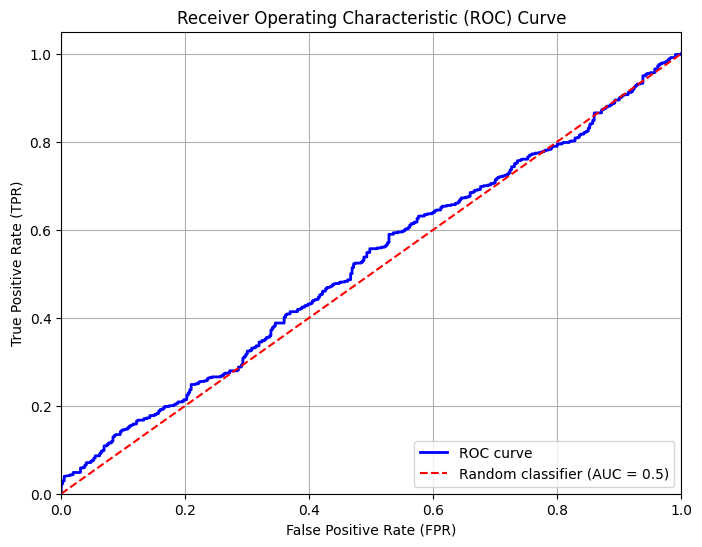

In [23]:
fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, t_hat)
# plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()